# Training pretrained Model for segmantic segmantation

In [1]:
import sys
import os
import numpy as np
import importlib

# Remontée de deux niveaux pour accéder à Data_loader
current_dir = os.getcwd()
project_root = os.path.normpath(os.path.join(current_dir, "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Chemin du projet : {project_root}")

# Import du module de chargement des données
module_name = "RSA_deep_working.Data_loader.class_data_loaders"

try:
    class_data_loaders = importlib.import_module(module_name)
    DirectoryRSAClass = class_data_loaders.DirectoryRSAClass
except ModuleNotFoundError as e:
    print(f"Erreur lors de l'importation du module {module_name} : {e}")
    sys.exit(1)

Chemin du projet : /home/loai/Documents/code/RSMLExtraction


Trying simple segmentation models from pytorch library 

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import rsml
import tifffile


from RSA_deep_working.Data_loader.class_data_loaders import DirectoryRSAClass

# importing pretrained segmentation model
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/uc1_segmentation")
global_step = 0


2025-03-26 00:21:47.898654: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-26 00:21:47.907424: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742944907.917673   62590 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742944907.920809   62590 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742944907.928569   62590 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Load dataset

Dimensions après division par 4 : 291 337
Dimensions ajustées (multiples de 32) : 288 320
754
754


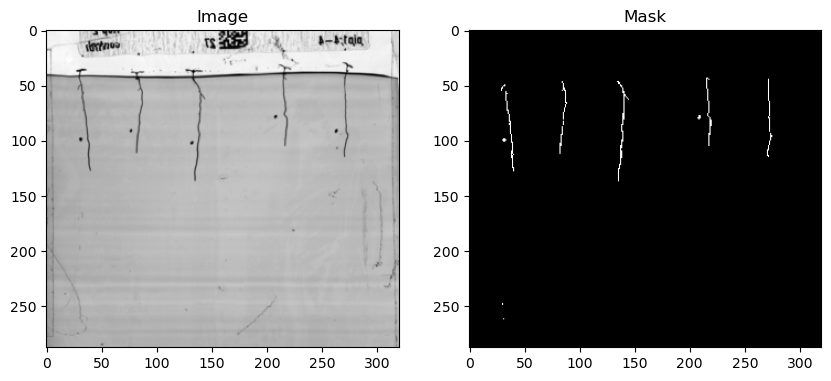

Image shape : (288, 320), mask shape : (288, 320)


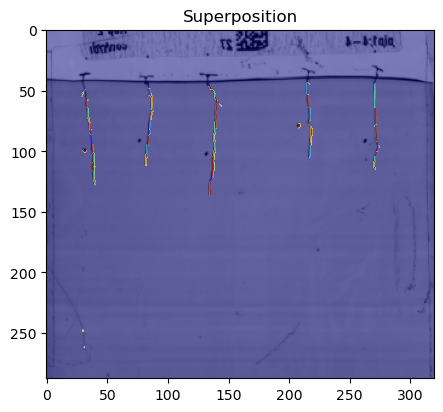

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

# Dimensions d'origine
H, W = (1166, 1348)

# Première étape : division par 4
H_temp = H // 4  # 1166 // 4 = 291
W_temp = W // 4  # 1348 // 4 = 337

# Deuxième étape : ajustement pour être divisible par 32
H_new = (H_temp // 32) * 32  # 291 // 32 = 9, 9 * 32 = 288
W_new = (W_temp // 32) * 32  # 337 // 32 = 10, 10 * 32 = 320

print("Dimensions après division par 4 :", H_temp, W_temp)
print("Dimensions ajustées (multiples de 32) :", H_new, W_new)

img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

mask_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.NEAREST),
])

class RSASeg2DDataset(Dataset):
    def __init__(self, rsa_dir_loader, img_transform=None, mask_transform=None):
        self.samples = []
        self.img_transform = img_transform
        self.mask_transform = mask_transform
        for loader in rsa_dir_loader.loaders:
            img_path = loader.image_stack_path
            mask_path = loader.date_map_path
            with tifffile.TiffFile(img_path) as tif:
                num_slices = len(tif.pages)
            for z in range(num_slices):
                self.samples.append((img_path, mask_path, z))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, z = self.samples[idx]
        img = tifffile.imread(img_path, key=z)
        mask_loaded = tifffile.imread(mask_path)
        mask = np.zeros_like(img)
        mask[mask_loaded <= z + 1] = 1
        mask[mask_loaded == 0] = 0
        mask = mask.astype(np.float32)


        if self.img_transform:
            img = self.img_transform(img)
            mask = self.mask_transform(mask)
        return img, mask

# Instanciation
base_directory = "/home/loai/Images/DataTest/UC1_data"
dir_loader = DirectoryRSAClass(base_directory, load_date_map=True, lazy=True)
rsa_dataset = RSASeg2DDataset(dir_loader, img_transform=img_transform, mask_transform=mask_transform)

print(len(rsa_dataset))

# plot image and mask
def plot_img_mask(img: torch.Tensor, mask: torch.Tensor):
    # img et mask ont shape [1, H, W]
    img_np  = img.squeeze(0).cpu().numpy()   # → (H, W)
    mask_np = mask.squeeze(0).cpu().numpy()

    fig, (ax0, ax1) = plt.subplots(1,2, figsize=(10,5))
    ax0.imshow(img_np, cmap='gray')
    ax0.set_title("Image")
    ax1.imshow(mask_np, cmap='gray')
    ax1.set_title("Mask")
    plt.show()
    print(f"Image shape : {img_np.shape}, mask shape : {mask_np.shape}")
    # Affichage de superposition
    fig, ax = plt.subplots(1,1, figsize=(5,5))
    ax.imshow(img_np, cmap='gray')
    ax.imshow(mask_np, cmap='jet', alpha=0.5)
    ax.set_title("Superposition")
    plt.show()


# Instanciation
print(len(rsa_dataset))

# Affichage d'un échantillon
img, mask = rsa_dataset[150]
plot_img_mask(img, mask)

In [4]:
train_set, val_set = torch.utils.data.random_split(rsa_dataset, [int(0.8*len(rsa_dataset)), len(rsa_dataset)-int(0.8*len(rsa_dataset))])
print(len(train_set) , len(val_set))

603 151


In [5]:
print(f"Nombre d'échantillons dans le jeu d'entraînement : {len(train_set)}")
print(f"Nombre d'échantillons dans le jeu de validation : {len(val_set)}")
print(f"Taille des images : {img.shape}")
print(f"Taille des masques : {mask.shape}")

Nombre d'échantillons dans le jeu d'entraînement : 603
Nombre d'échantillons dans le jeu de validation : 151
Taille des images : torch.Size([1, 288, 320])
Taille des masques : torch.Size([1, 288, 320])


## Unet

In [6]:
# Unet model
model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    # "efficientnet-b0",
    decoder_attention_type="scse",
    in_channels=1,
    classes=1
)

# Loss and optimizer
loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-6)

In [7]:
def evaluate(model, loader, device, loss_fn):
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    n = 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluation iteration", position=1, leave=False, dynamic_ncols=True):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss_val = loss_fn(preds, masks)
            total_loss += loss_val.item()

            probs = torch.sigmoid(preds)
            preds_bin = (probs > 0.5).float()
            intersection = (preds_bin * masks).sum(dim=(1,2,3))
            union = preds_bin.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) - intersection

            iou = (intersection / (union + 1e-6)).mean().item()
            dice = (2 * intersection / (preds_bin.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) + 1e-6)).mean().item()

            total_iou += iou
            total_dice += dice
            n += 1

    return total_loss / n, total_iou / n, total_dice / n


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

# put all to device
model.to(device)
loss.to(device)

# data loader optimization
train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=4)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=4)

Utilisation du device : cuda


torch.Size([16, 1, 288, 320]) torch.Size([16, 1, 288, 320])
torch.Size([16, 1, 288, 320])


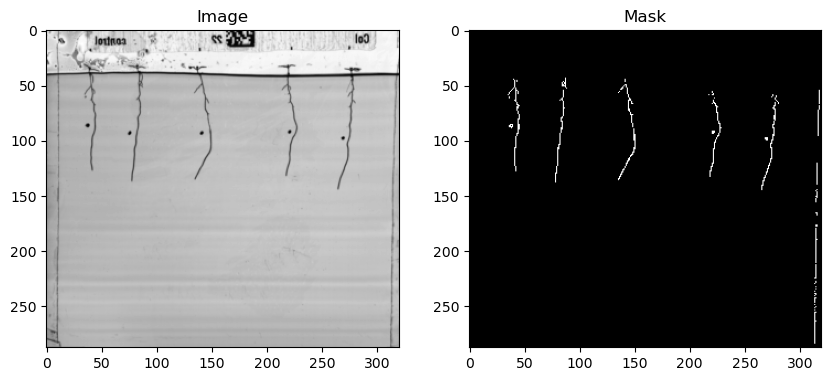

Image shape : (288, 320), mask shape : (288, 320)


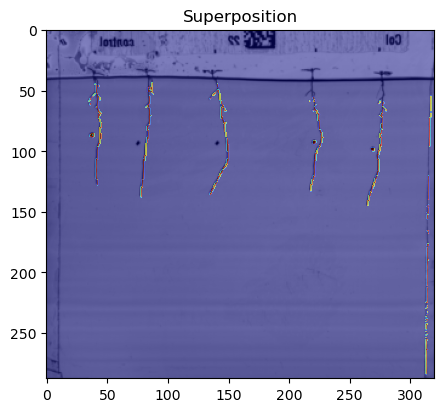

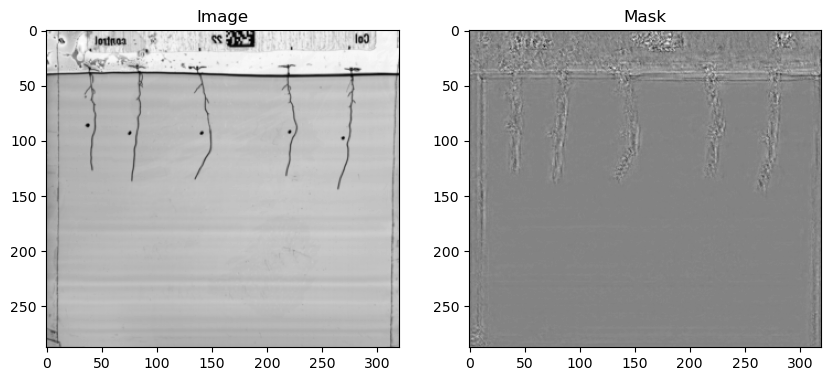

Image shape : (288, 320), mask shape : (288, 320)


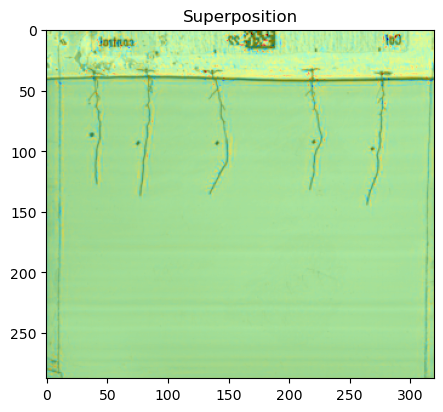

In [9]:
# print output shape and plot of model
batch = next(iter(train_loader))
imgs, masks = batch
imgs, masks = imgs.to(device), masks.to(device)
print(imgs.shape, masks.shape)
preds = model(imgs)
print(preds.shape)
plot_img_mask(imgs[0], masks[0])
plot_img_mask(imgs[0], preds[0].detach().cpu())

In [10]:
# free memory cuda
del imgs, masks, preds
torch.cuda.empty_cache()

In [11]:
# Training loop
num_epochs = 300
model.train()
for epoch in tqdm(range(num_epochs), desc=f"Training {num_epochs} epochs", position=0, leave=True):
    model.train()
    epoch_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc="Training iteration", position=1, leave=False, dynamic_ncols=True):
        
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()

        preds = model(imgs)
        loss_value = loss(preds, masks)
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()
        writer.add_scalar("Train/Loss", loss_value.item(), global_step)
        global_step += 1

    avg_train_loss = epoch_loss / len(train_loader)

    val_loss, val_iou, val_dice = evaluate(model, val_loader, device, loss)

    writer.add_scalar("Val/Loss", val_loss, epoch)
    writer.add_scalar("Val/IoU", val_iou, epoch)
    writer.add_scalar("Val/Dice", val_dice, epoch)

    # Log a sample prediction
    imgs, masks = next(iter(val_loader))
    imgs, masks = imgs.to(device), masks.to(device)
    with torch.no_grad():
        preds = model(imgs)
    pred_mask = (torch.sigmoid(preds) > 0.5).float()

    # Concatenate input / gt / pred into a grid
    sample = torch.cat([
        imgs[-1], 
        masks[-1], 
        pred_mask[-1]
    ], dim=2)  # horizontal concat

    writer.add_image("Sample/Image|GT|Pred", sample.cpu(), epoch)

    print(f"Epoch {epoch+1}/{num_epochs} — Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | IoU: {val_iou:.4f} | Dice: {val_dice:.4f}")


Training 300 epochs:   0%|          | 0/300 [00:00<?, ?it/s]

Training iteration:   0%|          | 0/38 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/300 — Train Loss: 0.6725 | Val Loss: 0.5791 | IoU: 0.0473 | Dice: 0.0898


Training iteration:   0%|          | 0/38 [00:00<?, ?it/s]

...

Evaluation iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 299/300 — Train Loss: 0.1949 | Val Loss: 0.1938 | IoU: 0.2564 | Dice: 0.3917


Training iteration:   0%|          | 0/38 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 300/300 — Train Loss: 0.1952 | Val Loss: 0.1936 | IoU: 0.2624 | Dice: 0.4004


In [12]:
# save the model
torch.save(model.state_dict(), "model.pth")
writer.close()

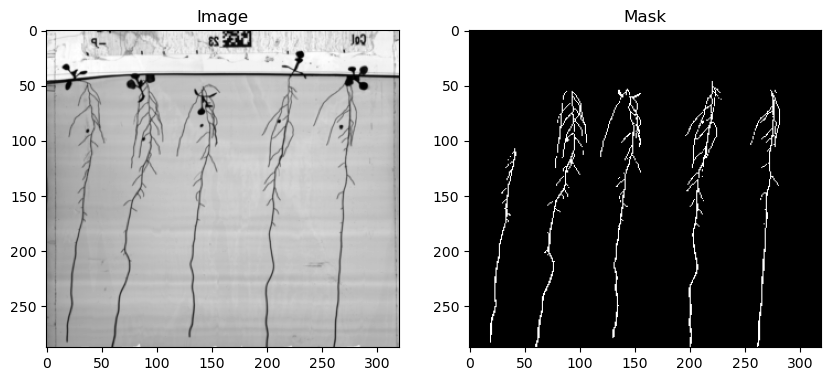

Image shape : (288, 320), mask shape : (288, 320)


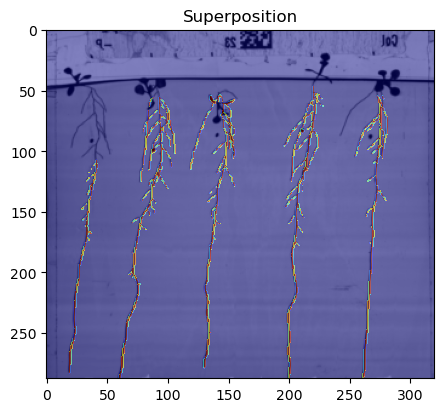

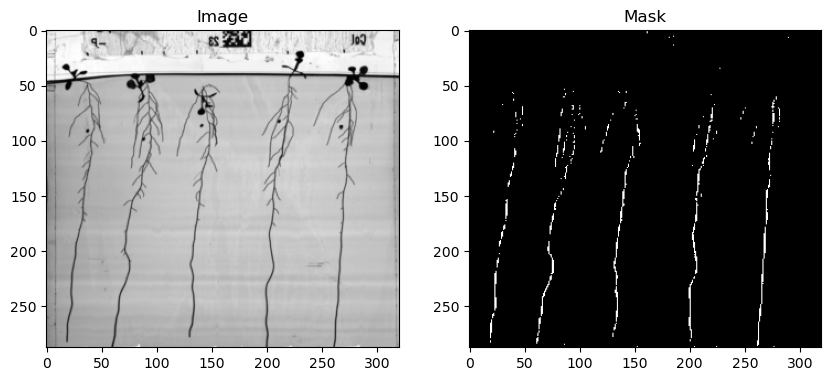

Image shape : (288, 320), mask shape : (288, 320)


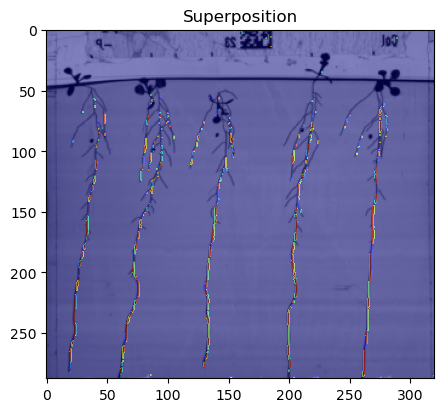

In [13]:
# visualize the prediction
imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(device), masks.to(device)
with torch.no_grad():
    preds = model(imgs)
pred_mask = (torch.sigmoid(preds) > 0.5).float()

plot_img_mask(imgs[0], masks[0])
plot_img_mask(imgs[0], pred_mask[0])